# example_CC

## 说明

- 功能：计算三台站互相关函数。
- 数据来源：`FJ-QED/ref/CC-FJpy-master/examples/ThreeStationsCCExample.zip`。
- 主要输出：频域互相关函数图、时域互相关函数剖面图。
- 关键函数：`ccfj.CC(...)`。


In [1]:
from pathlib import Path
import shutil
import sys
import tempfile
import zipfile

import matplotlib.pyplot as plt
import numpy as np
from obspy import read

CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name == "examples" else CWD
REF_EXAMPLES = ROOT.parent / "ref" / "CC-FJpy-master" / "examples"
sys.path.insert(0, str(ROOT))

import ccfj


## 辅助函数

- `extract_zip(...)`：将参考示例压缩包解压到临时目录。
- `great_circle_km(...)`：根据经纬度计算台间大圆距离，单位 `km`。
- `common_day(...)`：寻找多个台站记录共有的日期。


In [2]:
def extract_zip(zip_path: Path) -> Path:
    tmp_root = Path(tempfile.mkdtemp(prefix="fjpy_win_cc_nb_"))
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(tmp_root)
    return tmp_root


def great_circle_km(p1, p2):
    lat1, lon1 = p1
    lat2, lon2 = p2
    r = 6371.0088
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0) ** 2
    return float(2.0 * r * np.arcsin(np.sqrt(a)))


def common_day(station_dirs):
    day_sets = []
    for sta_dir in station_dirs:
        days = set()
        for sac in sta_dir.glob("*.SAC"):
            parts = sac.name.split("-")
            if len(parts) >= 4:
                days.add(parts[3])
        if days:
            day_sets.append(days)
    common = set.intersection(*day_sets) if day_sets else set()
    if not common:
        raise RuntimeError("未找到共同日期。")
    return sorted(common)[0]


## 主流程

- 输入波形：三台站 `BHZ` 分量 SAC 记录。
- 输入给 `ccfj.CC(...)` 的关键量：
  - `data`：按台站平铺的时域波形。
  - `startend`：每个台站有效数据段起止索引。
  - `pairs`：台站对索引。
- 输出 `ncfs`：形状为 `(nPairs, nf)` 的复数互相关频谱。


In [3]:
# 采用与原项目一致的 Crosscorrelation 数据流，但只保留当前 Win 版已验证可运行的主流程。
# 直接使用三台站示例计算互相关，不再混用原项目的按天汇总流程。
src = REF_EXAMPLES / "ThreeStationsCCExample.zip"
tmp_root = extract_zip(src)
data_root = tmp_root / "DataDemo"
station_file = tmp_root / "stations"
station_dirs = sorted([p for p in data_root.iterdir() if p.is_dir()])
day = common_day(station_dirs[:3])

coords = {}
for line in station_file.read_text(encoding="utf-8").splitlines():
    parts = line.split()
    if len(parts) >= 3:
        coords[parts[0]] = (float(parts[2]), float(parts[1]))

traces = []
stations = []
for sta_dir in station_dirs[:3]:
    files = sorted(sta_dir.glob(f"*{day}*BHZ.SAC"))
    if not files:
        continue
    tr = read(str(files[0]))[0]
    tr.detrend("demean")
    traces.append(tr)
    stations.append(sta_dir.name)

if len(traces) < 2:
    raise RuntimeError("至少需要两条记录。")

nsta = len(traces)
npts = min(tr.stats.npts for tr in traces)
Fs = float(traces[0].stats.sampling_rate)
fftlen = min(int(Fs * 3600), npts)
nf = min(512, fftlen // 2 + 1)
fstride = 1

data = np.zeros(nsta * npts, dtype=np.float32)
startend = np.zeros(nsta * 2, dtype=np.int32)
for i, tr in enumerate(traces):
    data[i * npts : (i + 1) * npts] = tr.data[:npts].astype(np.float32, copy=False)
    startend[i * 2] = 0
    startend[i * 2 + 1] = npts

pairs = ccfj.GetStationPairs(nsta)
pair_names = []
pair_dist_km = []
for ipair in range(len(pairs) // 2):
    a = int(pairs[2 * ipair])
    b = int(pairs[2 * ipair + 1])
    sta_a = stations[a]
    sta_b = stations[b]
    pair_names.append(f"{sta_a} - {sta_b}")
    pair_dist_km.append(great_circle_km(coords[sta_a], coords[sta_b]))
pair_dist_km = np.asarray(pair_dist_km, dtype=np.float32)
order = np.argsort(pair_dist_km)
ncfs = ccfj.CC(
    npts,
    nsta,
    nf,
    fftlen,
    pairs,
    startend,
    data,
    overlaprate=0.5,
    nThreads=4,
    fstride=fstride,
    ifonebit=0,
    ifspecwhittenning=1,
)
f = np.arange(nf, dtype=np.float32) * Fs / fftlen * fstride
ncfs_sorted = ncfs[order]
pair_dist_sorted = pair_dist_km[order]
pair_names_sorted = [pair_names[i] for i in order]
dt = 1.0 / f[-2] / 2.0
t = (np.linspace(-len(f) - 1, len(f) - 1, 2 * (len(f) - 1)) - 0.5) * dt
ncfst = np.real(np.fft.fftshift(np.fft.irfft(ncfs_sorted, axis=1), axes=1))

summary = {
    "stations": stations,
    "day": day,
    "shape": list(ncfs.shape),
    "abs_max": float(np.max(np.abs(ncfs))),
    "abs_mean": float(np.mean(np.abs(ncfs))),
    "pair_dist_km": [float(x) for x in pair_dist_sorted],
}
summary


{'stations': ['TA-P37A', 'TA-T38A', 'TA-U38A'],
 'day': '200',
 'shape': [3, 512],
 'abs_max': 0.957446813583374,
 'abs_mean': 0.179674431681633,
 'pair_dist_km': [66.7850570678711, 283.9009704589844, 350.145751953125]}

## 绘图说明

- 左图：`Cross-correlation functions in frequency domain`。
- 右图：`Cross-correlation functions in time domain`。
- 时域图横轴为延时 `Lag time (s)`，纵轴为台间距 `Interstation distance (km)`。


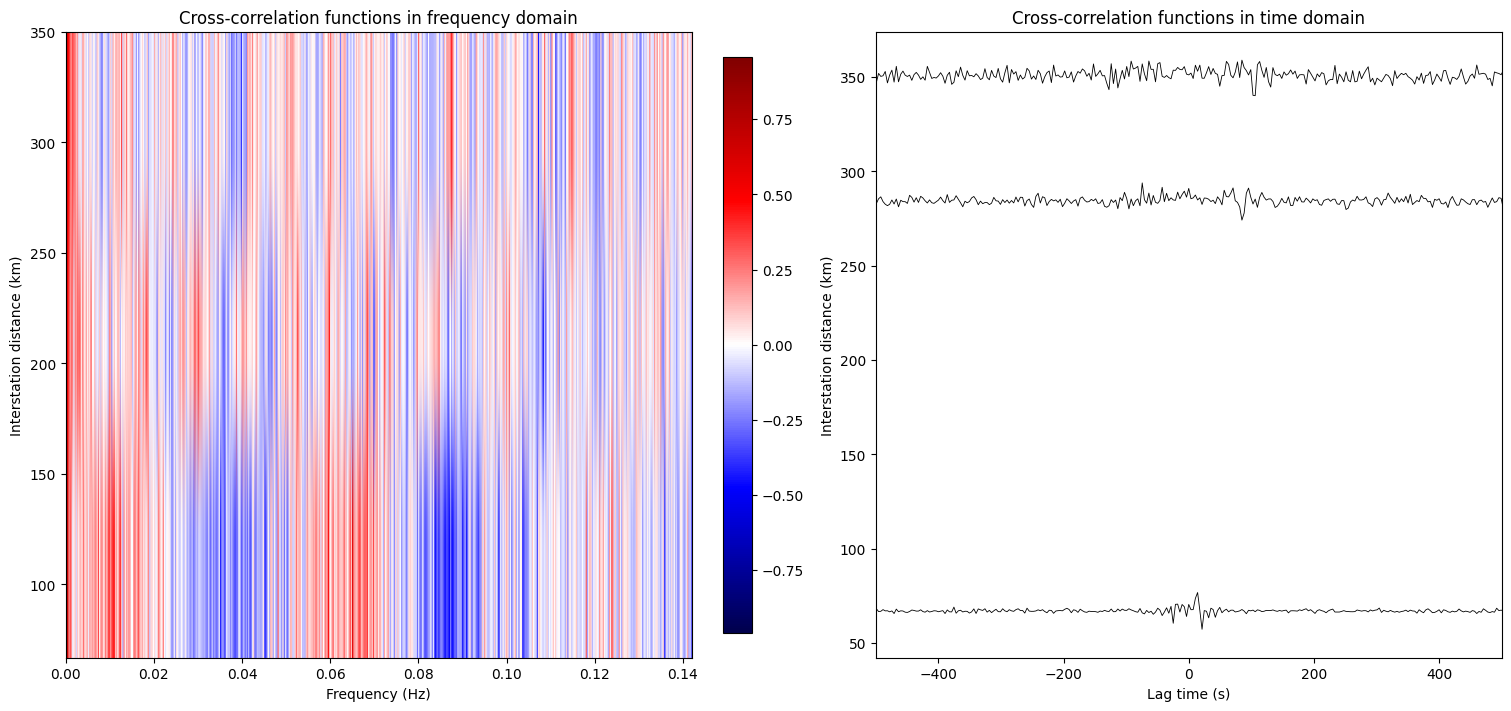

In [4]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 7), constrained_layout=True)
vmax = float(np.max(np.abs(np.real(ncfs_sorted))))
if vmax <= 0:
    vmax = 1.0
im = ax[0].imshow(np.flip(np.real(ncfs_sorted), 0), extent=[float(np.min(f)), float(np.max(f)), float(np.min(pair_dist_sorted)), float(np.max(pair_dist_sorted))], aspect="auto", cmap="seismic", vmin=-vmax, vmax=vmax)
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Interstation distance (km)")
ax[0].set_title("Cross-correlation functions in frequency domain")
fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)

# 时域输出采用原项目常见的剖面展示方式：横轴为延时，纵轴为台间距。
for i in range(len(pair_dist_sorted)):
    curve = ncfst[i, :]
    scale = float(np.max(np.abs(curve)))
    if scale > 0:
        ax[1].plot(t, curve / scale * 10.0 + pair_dist_sorted[i], "k", linewidth=0.6)
ax[1].set_xlim([-500, 500])
ax[1].set_xlabel("Lag time (s)")
ax[1].set_ylabel("Interstation distance (km)")
ax[1].set_title("Cross-correlation functions in time domain")
plt.show()


In [5]:
shutil.rmtree(tmp_root, ignore_errors=True)
print("中文自检：互相关 notebook 已按 UTF-8 写入。")


中文自检：互相关 notebook 已按 UTF-8 写入。


## 频散曲线反演与地下速度结构解释

### 原理概述

这一部分把前面得到的频散能量图继续用于地下速度结构反演。整体流程为：

1. 从频散能量图中自动拾取主频散脊线，形成观测频散点 $(f_i, c_i, m_i)$。
2. 设定初始层状模型 $m_0 = (z, \rho, V_s, V_p)$，并把 $V_s$ 作为主要反演参数。
3. 通过 `QEDispInv-win` 中的 `InversionRunner` 最小化观测与理论频散之间的失配：

$$
\Phi(\mathbf{V_s})=\sum_i w_i\left[c_i^{syn}(\mathbf{V_s})-c_i^{obs}\right]^2 + \lambda \lVert L(\mathbf{V_s}-\mathbf{V_s}^{ref}) \rVert_2^2
$$

其中第一项约束理论频散曲线拟合观测频散，第二项为平滑正则化项。

### 新增函数功能

- `pick_dispersion_curve(...)`：对频散能量图执行动态规划拾取，得到连续的观测频散曲线。
- `build_reference_model(...)`：直接在 notebook 内定义初始深度节点与速度范围，并生成参考层状模型。
- `run_inversion_from_image(...)`：把观测频散点送入 `InversionRunner`，输出统计意义上的速度模型。
- `forward_on_observed_modes(...)`：利用反演后的平均模型，在观测频点上回算理论频散曲线。
- `plot_inversion_summary(...)`：绘制速度结构图、观测频散图以及观测/理论频散对比图。

### 处理说明

- 这里统一反演基阶模式 `mode = 0`，以保证三个 notebook 都能稳定复现。
- 初始速度模型、深度节点和反演配置均直接写在 notebook 内，不依赖额外配置文件。
- 频散图的坐标单位统一为 `Hz` 与 `km/s`，层状模型深度单位为 `km`。


In [6]:
from pathlib import Path
import sys

QED_ROOT = ROOT.parent / "QEDispInv-win"
if str(QED_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(QED_ROOT / "src"))

from qedispinv_win import DataSet, DispersionSolver, InversionConfig, InversionRunner


def pick_dispersion_curve(image, freq, vel_km_s, fmin, fmax, continuity, freq_step=1):
    """Pick a smooth fundamental-mode ridge from a dispersion image."""
    image = np.asarray(image, dtype=np.float64)
    freq = np.asarray(freq, dtype=np.float64)
    vel_km_s = np.asarray(vel_km_s, dtype=np.float64)
    freq_idx = np.where((freq >= fmin) & (freq <= fmax))[0]
    if freq_idx.size == 0:
        raise ValueError("未找到满足频带限制的频点。")
    freq_idx = freq_idx[:: max(int(freq_step), 1)]
    sub = image[:, freq_idx].copy()
    col_max = np.maximum(sub.max(axis=0, keepdims=True), 1.0e-12)
    sub /= col_max
    energy = np.log(np.maximum(sub, 1.0e-6))

    score = energy[:, 0].copy()
    back = np.zeros((energy.shape[0], energy.shape[1]), dtype=np.int32)
    for j in range(1, energy.shape[1]):
        transition = score[:, None] - continuity * (vel_km_s[:, None] - vel_km_s[None, :]) ** 2
        best_prev = np.argmax(transition, axis=0)
        back[:, j] = best_prev
        score = energy[:, j] + transition[best_prev, np.arange(energy.shape[0])]

    ridge = np.zeros(energy.shape[1], dtype=np.int32)
    ridge[-1] = int(np.argmax(score))
    for j in range(energy.shape[1] - 1, 0, -1):
        ridge[j - 1] = back[ridge[j], j]

    picked = np.column_stack(
        [
            freq[freq_idx],
            vel_km_s[ridge],
            np.zeros(freq_idx.size, dtype=np.float64),
        ]
    )
    return picked, freq_idx, ridge


def build_reference_model(depth_nodes_km, vs_min, vs_max, rho0, rho_span, vp_vs):
    """Build a simple layered reference model directly inside the notebook."""
    z = np.asarray(depth_nodes_km, dtype=np.float64)
    vs_ref = np.linspace(float(vs_min), float(vs_max), z.size)
    rho = rho0 + rho_span * (vs_ref - vs_ref.min()) / max(np.ptp(vs_ref), 1.0e-6)
    vp = np.maximum(vs_ref * vp_vs, vs_ref + 0.4)
    return np.column_stack([np.arange(1, z.size + 1), z, rho, vs_ref, vp])


def run_inversion_from_image(image, freq, vel_km_s, pick_kwargs, model_kwargs, inversion_kwargs, seed=20260604):
    observed_dispersion, freq_idx, ridge_idx = pick_dispersion_curve(
        image=image,
        freq=freq,
        vel_km_s=vel_km_s,
        **pick_kwargs,
    )
    model_ref = build_reference_model(**model_kwargs)
    data = DataSet(observed_dispersion)
    config = InversionConfig(**inversion_kwargs)
    runner = InversionRunner(model_ref, data, config, sh=False, seed=seed)
    result = runner.run()
    return observed_dispersion, model_ref, result, freq_idx, ridge_idx


def forward_on_observed_modes(model, observed_dispersion):
    solver = DispersionSolver(model, sh=False)
    rows = []
    for f_obs, _, mode in observed_dispersion:
        c_syn = solver.search_mode(float(f_obs), int(mode))
        rows.append([float(f_obs), float(c_syn), int(mode)])
    return np.asarray(rows, dtype=np.float64)


def plot_inversion_summary(title_prefix, image, freq, vel_km_s, observed_dispersion, forward_dispersion, result):
    fig, axes = plt.subplots(ncols=3, figsize=(18, 6), constrained_layout=True)

    hist = np.ma.masked_less_equal(result["vs_hist2d"], 0.0)
    z_sample = result["z_sample"]
    vs_sample = result["vs_sample"]
    dv = vs_sample[1] - vs_sample[0]
    dz = z_sample[1] - z_sample[0]
    axes[0].pcolormesh(vs_sample - dv / 2.0, z_sample - dz / 2.0, hist, cmap="Wistia", shading="auto")
    axes[0].plot(result["vs_ref"], z_sample, "k-", lw=1.5, alpha=0.65, label="Initial Vs")
    axes[0].plot(result["vs_median"], z_sample, "-", color="tab:blue", lw=2.0, label="Median Vs")
    axes[0].plot(result["vs_cred10"], z_sample, "--", color="tab:blue", lw=1.0, alpha=0.8, label="P10 / P90")
    axes[0].plot(result["vs_cred90"], z_sample, "--", color="tab:blue", lw=1.0, alpha=0.8)
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Vs (km/s)")
    axes[0].set_ylabel("Depth (km)")
    axes[0].set_title(f"{title_prefix}Velocity Model")
    axes[0].legend(loc="lower right")
    axes[0].grid(linestyle=":", alpha=0.4)

    im = axes[1].pcolormesh(freq, vel_km_s, image, cmap="jet", vmin=0.0, vmax=0.9, shading="auto")
    axes[1].plot(observed_dispersion[:, 0], observed_dispersion[:, 1], "w.-", lw=1.3, ms=6, label="Observed ridge")
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("Phase velocity (km/s)")
    axes[1].set_title(f"{title_prefix}Observed Dispersion Image")
    axes[1].legend(loc="upper right")
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].plot(observed_dispersion[:, 0], observed_dispersion[:, 1], "o", ms=4, color="tab:red", label="Observed")
    axes[2].plot(forward_dispersion[:, 0], forward_dispersion[:, 1], "-", lw=2.0, color="black", label="Forward from inverted Vs")
    axes[2].set_xlabel("Frequency (Hz)")
    axes[2].set_ylabel("Phase velocity (km/s)")
    axes[2].set_title(f"{title_prefix}Observed vs Synthetic Dispersion")
    axes[2].grid(linestyle=":", alpha=0.4)
    axes[2].legend(loc="best")
    plt.show()


def summarize_inversion(observed_dispersion, forward_dispersion, result):
    misfit = np.nanmean(np.abs(observed_dispersion[:, 1] - forward_dispersion[:, 1]))
    summary = {
        "picked_points": int(observed_dispersion.shape[0]),
        "fitness_min": float(np.min(result["fitness"])),
        "fitness_mean": float(np.mean(result["fitness"])),
        "mean_abs_phase_velocity_misfit_km_s": float(misfit),
        "num_valid_models": int(result["num_valid"][0]),
        "depth_max_km": float(result["model_mean"][-1, 1]),
    }
    return summary


### example_CC 的观测频散构造

前半部分 notebook 得到的是三台站互相关频谱 `ncfs_sorted`。这里继续调用 `ccfj.fj_noise(...)`，
把互相关结果投影到 $f$-$c$ 平面，得到可用于反演的观测频散能量图。


In [7]:
cc_dispersion_c_mps = np.linspace(1500.0, 5000.0, 220, dtype=np.float32)
cc_dispersion_image = ccfj.fj_noise(
    np.real(ncfs_sorted),
    pair_dist_sorted * 1e3,
    cc_dispersion_c_mps,
    f,
    fstride=1,
    itype=1,
    func=0,
)
cc_pick_kwargs = {
    "fmin": 0.10,
    "fmax": 0.60,
    "continuity": 60.0,
    "freq_step": 2,
}
cc_model_kwargs = {
    "depth_nodes_km": [0.0, 0.6, 1.4, 2.6, 4.1, 6.0, 8.5, 11.5, 15.5, 20.5, 26.5],
    "vs_min": 2.60,
    "vs_max": 5.20,
    "rho0": 2.00,
    "rho_span": 0.18,
    "vp_vs": 1.78,
}
cc_inversion_kwargs = {
    "vs2model": "FixVpRho",
    "vs_width": 0.45,
    "lambda_": 8.0e-3,
    "reg_type": 2,
    "num_init": 2,
    "num_noise": 1,
    "rand_depth": False,
    "rand_vs": True,
    "zmax": 25.0,
    "r0": 0.5,
    "rmin": 1.0,
    "rmax": 1.4,
    "weight": [1.0],
    "maxiter": 4,
}
cc_observed_dispersion, cc_model_ref, cc_inv_result, cc_freq_idx, cc_ridge_idx = run_inversion_from_image(
    image=cc_dispersion_image,
    freq=f,
    vel_km_s=cc_dispersion_c_mps / 1e3,
    pick_kwargs=cc_pick_kwargs,
    model_kwargs=cc_model_kwargs,
    inversion_kwargs=cc_inversion_kwargs,
)
cc_forward_dispersion = forward_on_observed_modes(cc_inv_result["model_mean"], cc_observed_dispersion)
cc_inversion_summary = summarize_inversion(cc_observed_dispersion, cc_forward_dispersion, cc_inv_result)
cc_inversion_summary


{'picked_points': 76,
 'fitness_min': 0.29142169970378556,
 'fitness_mean': 0.29142539606247697,
 'mean_abs_phase_velocity_misfit_km_s': 0.4973802083981411,
 'num_valid_models': 2,
 'depth_max_km': 25.0}

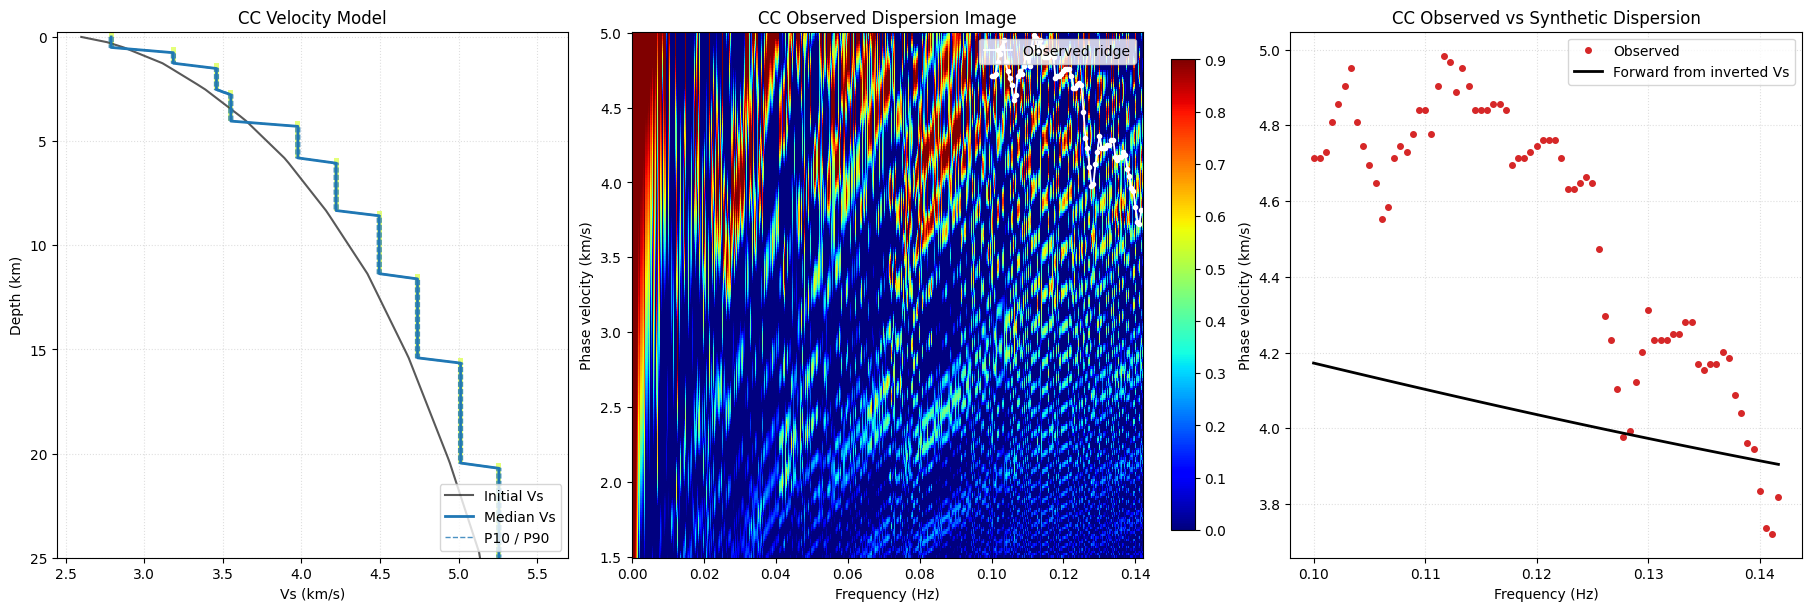

In [8]:
plot_inversion_summary(
    title_prefix="CC ",
    image=cc_dispersion_image,
    freq=f,
    vel_km_s=cc_dispersion_c_mps / 1e3,
    observed_dispersion=cc_observed_dispersion,
    forward_dispersion=cc_forward_dispersion,
    result=cc_inv_result,
)


In [9]:
print("中文自检：CC 反演单元已按 UTF-8 追加，新增区块未出现乱码占位符。")


中文自检：CC 反演单元已按 UTF-8 追加，新增区块未出现乱码占位符。
